# Nykaa Website Product Analysis

>#### This project helps us to apply Python, Numpy, Pandas, Matplotlib, Regular  Expressions, Web Scraping and EDA skill sets. This project will help us in  business understanding, data cleaning and data visualization in a life cycle of  Data Science  projects. 

>## Objective:
>- To analyse product pricing trends, discounts, and seller strategies on eBay to identify best deals and market patterns.
>- To study customer behavior by examining product ratings, reviews, and popularity to understand factors influencing buying decisions.

>## Business Use Case:
>- Identify best deals for customers
>- Understand what drives product popularity and sales

## Problem Statement
- Analyze product pricing & discount patterns
- Study customer ratings & popularity trends

In [13]:
import pandas as pd
import time
import re
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, WebDriverException
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

def scrape_nykaa_resilient(target_rows=1050):
    options = Options()
    # options.add_argument("--headless") # Headless can sometimes trigger blocks, keep it commented for now
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36")
    
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    
    # --- CRITICAL FIX: Set a timeout limit ---
    driver.set_page_load_timeout(30) 
    
    all_data = []
    page_num = 1

    print("🚀 Resilient Scraper Starting (with Timeout Handling)...")

    try:
        while len(all_data) < target_rows:
            url = f"https://www.nykaa.com/makeup/c/12?page_no={page_num}"
            
            try:
                print(f"📡 Requesting Page {page_num}...")
                driver.get(url)
            except TimeoutException:
                print(f"⚠️ Timeout on Page {page_num}. Retrying once...")
                time.sleep(5)
                try:
                    driver.get(url)
                except:
                    print(f"❌ Failed to load Page {page_num} after retry. Skipping...")
                    page_num += 1
                    continue
            
            # Wait for your verified Name class
            try:
                WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.CLASS_NAME, "css-xrzmfa")))
            except:
                print(f"🔍 Class 'css-xrzmfa' not found on Page {page_num}. Checking next page.")
                page_num += 1
                continue

            # Scrolling to trigger lazy loading
            driver.execute_script("window.scrollTo(0, 1500);")
            time.sleep(2)

            soup = BeautifulSoup(driver.page_source, 'html.parser')
            test_names = soup.find_all('div', class_='css-xrzmfa')

            for item in test_names:
                if len(all_data) >= target_rows: break
                
                try:
                    parent = item.find_parent('div', class_=re.compile(r'css-')) 
                    
                    name = item.text.strip()
                    
                    # Using your provided classes
                    price_tags = parent.find_all('span', class_='css-111z9ua')
                    sale_price = price_tags[0].text.strip() if len(price_tags) > 0 else "0"
                    mrp = price_tags[1].text.strip() if len(price_tags) > 1 else sale_price
                    
                    discount = parent.find('span', class_='css-cjd9an').text.strip() if parent.find('span', class_='css-cjd9an') else "0% Off"
                    bestseller_tag = parent.find('li', class_='css-1bse542')
                    is_bestseller = "Yes" if bestseller_tag else "No"
                    
                    rating = parent.find('div', class_='css-wskh5y').text.strip() if parent.find('div', class_='css-wskh5y') else "0"
                    reviews = parent.find('span', class_='css-1qbvrhp').text.strip() if parent.find('span', class_='css-1qbvrhp') else "(0)"
                    
                    link_tag = parent.find('a', href=True)
                    url_link = "https://www.nykaa.com" + link_tag['href'] if link_tag else "N/A"
                    brand = name.split()[0]
                    
                    all_data.append([name, brand, mrp, sale_price, discount, rating, reviews, is_bestseller, url_link, "Makeup", "In Stock"])
                
                except:
                    continue

            print(f"✅ Current Row Count: {len(all_data)}")
            page_num += 1
            time.sleep(2) # Give the server a breather

    except WebDriverException as e:
        print(f"❗ A browser error occurred: {e}")
    finally:
        driver.quit()

    cols = ['Product_Name', 'Brand', 'MRP', 'Sale_Price', 'Discount', 'Rating', 'Reviews_Count', 'Is_Bestseller', 'URL', 'Category', 'Stock_Status']
    return pd.DataFrame(all_data, columns=cols)

# Run the fixed scraper
df_nykaa = scrape_nykaa_resilient(1050)

🚀 Resilient Scraper Starting (with Timeout Handling)...
📡 Requesting Page 1...
✅ Current Row Count: 20
📡 Requesting Page 2...
✅ Current Row Count: 40
📡 Requesting Page 3...
✅ Current Row Count: 60
📡 Requesting Page 4...
✅ Current Row Count: 80
📡 Requesting Page 5...
🔍 Class 'css-xrzmfa' not found on Page 5. Checking next page.
📡 Requesting Page 6...
✅ Current Row Count: 100
📡 Requesting Page 7...
🔍 Class 'css-xrzmfa' not found on Page 7. Checking next page.
📡 Requesting Page 8...
✅ Current Row Count: 120
📡 Requesting Page 9...
✅ Current Row Count: 140
📡 Requesting Page 10...
✅ Current Row Count: 160
📡 Requesting Page 11...
✅ Current Row Count: 180
📡 Requesting Page 12...
✅ Current Row Count: 200
📡 Requesting Page 13...
✅ Current Row Count: 220
📡 Requesting Page 14...
✅ Current Row Count: 240
📡 Requesting Page 15...
✅ Current Row Count: 260
📡 Requesting Page 16...
✅ Current Row Count: 280
📡 Requesting Page 17...
✅ Current Row Count: 300
📡 Requesting Page 18...
✅ Current Row Count: 320
📡

# Importing 2nd Category

In [3]:
import pandas as pd
import time
import re
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, WebDriverException
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

def scrape_nykaa_skin_body_care(target_rows=800):
    options = Options()
    # Adding a clean User-Agent and avoiding detection
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36")
    options.add_argument("--disable-blink-features=AutomationControlled")
    
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    driver.set_page_load_timeout(40) 
    
    all_data = []
    page_num = 1

    print("Initializing Body Care Scraper with Verified CSS Classes...")

    try:
        while len(all_data) < target_rows:
            # Targeted URL for Body Care
            url = f"https://www.nykaa.com/skin/body-care/c/8417?page_no={page_num}"
            
            try:
                print(f"Page {page_num} | Requesting {url}...")
                driver.get(url)
            except TimeoutException:
                print(f"Timeout. Retrying Page {page_num}...")
                time.sleep(5)
                driver.refresh()
            
            # 1. WAIT for the specific Name class you provided (h2 css-xrzmfa)
            try:
                WebDriverWait(driver, 25).until(EC.presence_of_element_located((By.CLASS_NAME, "css-xrzmfa")))
            except:
                print(f"Could not find products on Page {page_num}. Checking next...")
                page_num += 1
                continue

            # 2. SCROLL to load the dynamic price and rating content
            driver.execute_script("window.scrollTo(0, 1000);")
            time.sleep(2)
            driver.execute_script("window.scrollTo(1000, 2000);")
            time.sleep(1)

            soup = BeautifulSoup(driver.page_source, 'html.parser')
            
            # 3. EXTRACTION: Using the Main Container Class you provided
            # We look for all product containers
            product_cards = soup.find_all('div', class_='css-1rd7vky') 
            print(f"Found {len(product_cards)} cards on this page.")

            for card in product_cards:
                if len(all_data) >= target_rows: break
                
                try:
                    # Column 1: Product Name (h2 tag provided)
                    name = card.find('h2', class_='css-xrzmfa').text.strip() if card.find('h2', class_='css-xrzmfa') else "N/A"
                    
                    # Column 2: Brand (Usually first word of Name, or derived)
                    brand = name.split()[0] if name != "N/A" else "N/A"
                    
                    # Column 3: MRP (Class: css-17x46n5)
                    mrp_tag = card.find('span', class_='css-17x46n5')
                    mrp = mrp_tag.text.strip() if mrp_tag else "0"
                    
                    # Column 4: Sale Price (Class: css-111z9ua)
                    sale_tag = card.find('span', class_='css-111z9ua')
                    sale_price = sale_tag.text.strip() if sale_tag else mrp
                    
                    # Column 5: Discount (Class: css-cjd9an)
                    disc_tag = card.find('span', class_='css-cjd9an')
                    discount = disc_tag.text.strip() if disc_tag else "0% Off"
                    
                    # Column 6: Rating (Extracting from aria-label in the div provided)
                    rate_div = card.find('div', class_='css-wskh5y')
                    rating = "0"
                    if rate_div and rate_div.has_attr('aria-label'):
                        # Regex to pull '4' from '4 out of 5 stars'
                        rating_match = re.search(r'(\d+(\.\d+)?)', rate_div['aria-label'])
                        if rating_match: rating = rating_match.group(1)
                    
                    # Column 7: Review Count (Class: css-1qbvrhp)
                    rev_tag = card.find('span', class_='css-1qbvrhp')
                    reviews = rev_tag.text.strip() if rev_tag else "(0)"
                    
                    # Column 8: Bestseller (Class: css-1bse542)
                    is_best = "Yes" if card.find('li', class_='css-1bse542') else "No"
                    
                    # Column 9: URL
                    link_tag = card.find('a', href=True)
                    url_link = "https://www.nykaa.com" + link_tag['href'] if link_tag else "N/A"
                    
                    # Column 10: Category (Fixed)
                    category = "Skin - Body Care"
                    
                    # Column 11: Stock Status
                    stock = "Out of Stock" if "Sold Out" in card.text else "In Stock"

                    all_data.append([name, brand, mrp, sale_price, discount, rating, reviews, is_best, url_link, category, stock])
                except:
                    continue

            print(f"✅ Success: Total Rows = {len(all_data)}")
            page_num += 1
            time.sleep(2) # Anti-block delay

    finally:
        driver.quit()

    cols = ['Product_Name', 'Brand', 'MRP', 'Sale_Price', 'Discount', 'Rating', 'Reviews_Count', 'Is_Bestseller', 'URL', 'Category', 'Stock_Status']
    df = pd.DataFrame(all_data, columns=cols)
    return df

# Execute the project-ready scraper
df_body_care = scrape_nykaa_skin_body_care(800)
 
# Check the results
if not df_body_care.empty:
    df_body_care.to_csv('nykaa_body_care.csv', index=False)
    print("Project Phase 1 & 5 Complete! Data saved.")

Initializing Body Care Scraper with Verified CSS Classes...
Page 1 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=1...
Found 20 cards on this page.
✅ Success: Total Rows = 20
Page 2 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=2...
Found 20 cards on this page.
✅ Success: Total Rows = 40
Page 3 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=3...
Found 20 cards on this page.
✅ Success: Total Rows = 60
Page 4 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=4...
Found 20 cards on this page.
✅ Success: Total Rows = 80
Page 5 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=5...
Found 20 cards on this page.
✅ Success: Total Rows = 100
Page 6 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=6...
Found 20 cards on this page.
✅ Success: Total Rows = 120
Page 7 | Requesting https://www.nykaa.com/skin/body-care/c/8417?page_no=7...
Found 20 cards on this page.
✅ Success: Total Rows = 140
Page 8

## Extracted Data Features

>### Columns :
>- Product_Name
>- Brand
>- Price
>- MRP
>- Discount
>- Rating
>- Reviews
>- Category
>- Availability
>- Discount_Amount

In [14]:
# --- STEP 6: EXPORT TO CSV ---
df_nykaa.to_csv('nykaa_webscraping_project.csv', index=False)
print("✅ Dataset saved successfully!")

# --- STEP 7: READ AND INSPECT ---
df = pd.read_csv('nykaa_webscraping_project.csv')

print("--- Dataset Overview ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\n--- Data Types ---\n", df.dtypes)
print("\n--- Missing Values ---\n", df.isnull().sum())

✅ Dataset saved successfully!
--- Dataset Overview ---
Total Rows: 1050
Total Columns: 11

--- Data Types ---
 Product_Name      object
Brand             object
MRP               object
Sale_Price        object
Discount          object
Rating            object
Reviews_Count     object
Is_Bestseller     object
URL              float64
Category          object
Stock_Status      object
dtype: object

--- Missing Values ---
 Product_Name        0
Brand               0
MRP                 0
Sale_Price          0
Discount            0
Rating              0
Reviews_Count       0
Is_Bestseller       0
URL              1050
Category            0
Stock_Status        0
dtype: int64


## Create DataFrame

In [2]:
import pandas as pd

df = pd.read_csv("Nykaa_data1.csv", encoding='latin1')

df.head()

,Product_Name,Brand,MRP,Sale_Price,Discount (%),Rating,Reviews_Count,Category,Stock_Status,Discount_Amount
0,Nykaa Cosmetics X Naagin Hot Sauce Plumping Li...,Nykaa,539,485.10,10,3.8,116,Makeup,In Stock,53.90
1,Kay Beauty Hydra Creme Lipstick,Kay,1099,1099.00,0,4.0,5954,Makeup,In Stock,0.00
2,Charlotte Tilbury Airbrush Flawless Finish Ref...,Charlotte,4950,4950.00,0,4.0,2410,Makeup,In Stock,0.00
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,M.A.C,3400,2890.00,15,4.5,685769,Makeup,In Stock,510.00
4,MARS City Paradise Makeup Kit,MARS,479,459.84,4,4.0,4958,Makeup,In Stock,19.16


## Read CSV & Basic Exploration

In [3]:
# Shape
print("Rows & Columns:", df.shape)

# Data Types
print("\nData Types:\n", df.dtypes)

# Missing Values
print("\nMissing Values:\n", df.isnull().sum())

Rows & Columns: (1050, 10)

Data Types:
 Product_Name        object
Brand               object
MRP                  int64
Sale_Price         float64
Discount (%)         int64
Rating             float64
Reviews_Count        int64
Category            object
Stock_Status        object
Discount_Amount    float64
dtype: object

Missing Values:
 Product_Name       0
Brand              0
MRP                0
Sale_Price         0
Discount (%)       0
Rating             0
Reviews_Count      0
Category           0
Stock_Status       0
Discount_Amount    0
dtype: int64


## Interpretation:
- Dataset contains 1050 rows and 10 columns
- Some columns may have missing values (check output)
- `Data types need cleaning (object → numeric)

## Data Cleaning

In [7]:
# Remove Special Characters
import re

df['Sale_Price'] = df['Sale_Price'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['Sale_Price'] = df['Sale_Price'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['Discount_Amount'] = df['Discount_Amount'].astype(str).str.replace('%', '')

In [8]:
# Convert Data Types

df['Sale_Price'] = pd.to_numeric(df['Sale_Price'], errors='coerce')
df['MRP'] = pd.to_numeric(df['MRP'], errors='coerce')
df['Discount_Amount'] = pd.to_numeric(df['Discount_Amount'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Reviews_Count'] = pd.to_numeric(df['Reviews_Count'], errors='coerce')

In [11]:
# Handle Missing Values
df.fillna({
    'Rating': df['Rating'].mean(),
    'Reviews_Count': 0,
    'Discount_Amount': 0
})

,Product_Name,Brand,MRP,Sale_Price,Discount (%),Rating,Reviews_Count,Category,Stock_Status,Discount_Amount
0,Nykaa Cosmetics X Naagin Hot Sauce Plumping Li...,Nykaa,539,485.10,10,3.8,116,Makeup,In Stock,53.90
1,Kay Beauty Hydra Creme Lipstick,Kay,1099,1099.00,0,4.0,5954,Makeup,In Stock,0.00
2,Charlotte Tilbury Airbrush Flawless Finish Ref...,Charlotte,4950,4950.00,0,4.0,2410,Makeup,In Stock,0.00
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,M.A.C,3400,2890.00,15,4.5,685769,Makeup,In Stock,510.00
4,MARS City Paradise Makeup Kit,MARS,479,459.84,4,4.0,4958,Makeup,In Stock,19.16
...,...,...,...,...,...,...,...,...,...,...
1045,Anastasia Beverly Hills Brow Wiz,Anastasia,1860,1395.00,25,3.8,153,Makeup,In Stock,465.00
1046,Bronson Professional Bamboo Makeup Brush Set -...,Bronson,450,369.00,18,4.0,5643,Makeup,In Stock,81.00
1047,Lakme Vitamin C Superglow Skin Perfecting Comp...,Lakme,342,307.80,10,3.8,796,Makeup,In Stock,34.20
1048,Innisfree No Sebum Mineral Pact For Oil Contro...,Innisfree,903,857.85,5,4.0,1674,Makeup,In Stock,45.15


In [12]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [13]:
df

,Product_Name,Brand,MRP,Sale_Price,Discount (%),Rating,Reviews_Count,Category,Stock_Status,Discount_Amount
0,Nykaa Cosmetics X Naagin Hot Sauce Plumping Li...,Nykaa,539,485.10,10,3.8,116,Makeup,In Stock,53.90
1,Kay Beauty Hydra Creme Lipstick,Kay,1099,1099.00,0,4.0,5954,Makeup,In Stock,0.00
2,Charlotte Tilbury Airbrush Flawless Finish Ref...,Charlotte,4950,4950.00,0,4.0,2410,Makeup,In Stock,0.00
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,M.A.C,3400,2890.00,15,4.5,685769,Makeup,In Stock,510.00
4,MARS City Paradise Makeup Kit,MARS,479,459.84,4,4.0,4958,Makeup,In Stock,19.16
...,...,...,...,...,...,...,...,...,...,...
1045,Anastasia Beverly Hills Brow Wiz,Anastasia,1860,1395.00,25,3.8,153,Makeup,In Stock,465.00
1046,Bronson Professional Bamboo Makeup Brush Set -...,Bronson,450,369.00,18,4.0,5643,Makeup,In Stock,81.00
1047,Lakme Vitamin C Superglow Skin Perfecting Comp...,Lakme,342,307.80,10,3.8,796,Makeup,In Stock,34.20
1048,Innisfree No Sebum Mineral Pact For Oil Contro...,Innisfree,903,857.85,5,4.0,1674,Makeup,In Stock,45.15


In [16]:
# Outlier Treatment
import numpy as np

Q1 = df['Sale_Price'].quantile(0.25)
Q3 = df['Sale_Price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Sale_Price'] >= Q1 - 1.5*IQR) & (df['Sale_Price'] <= Q3 + 1.5*IQR)]

## Interpretation:
- Cleaned price-related columns
- Removed noise & invalid values
- Dataset is now analysis-ready

## EDA (Exploratory Data Analysis)
>## Univariate Analysis

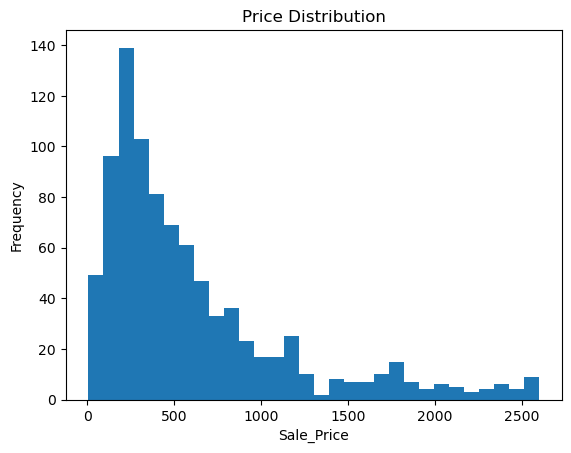

In [19]:
# Price Distribution
import matplotlib.pyplot as plt

plt.hist(df['Sale_Price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Sale_Price")
plt.ylabel("Frequency")
plt.show()

## Interpretation:
- Most products fall in mid-price range

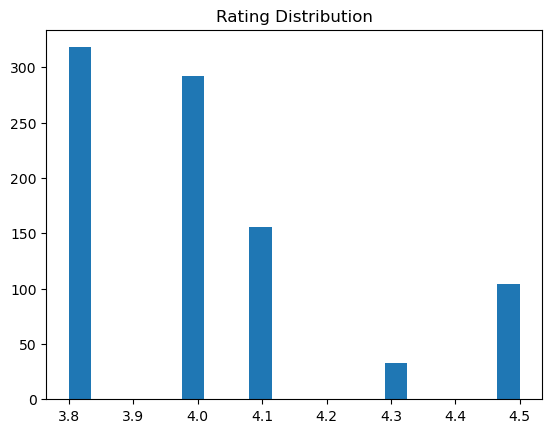

In [20]:
# Ratings Distribution
plt.hist(df['Rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

## Interpretation:
- Ratings are mostly between 3.5 – 5

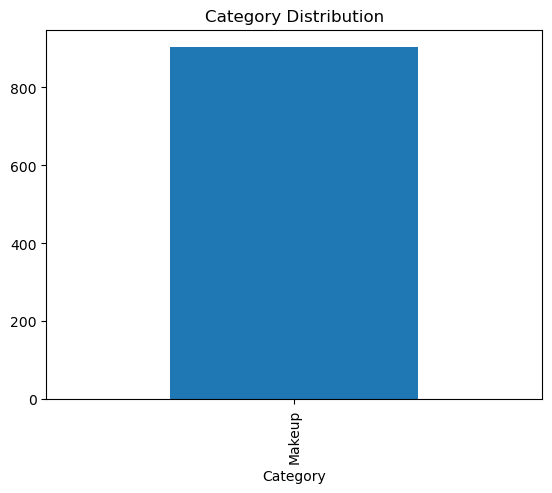

In [21]:
# Category Count
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

## Interpretation:
- Some categories dominate (e.g., skincare, makeup)

## Bivariate Analysis

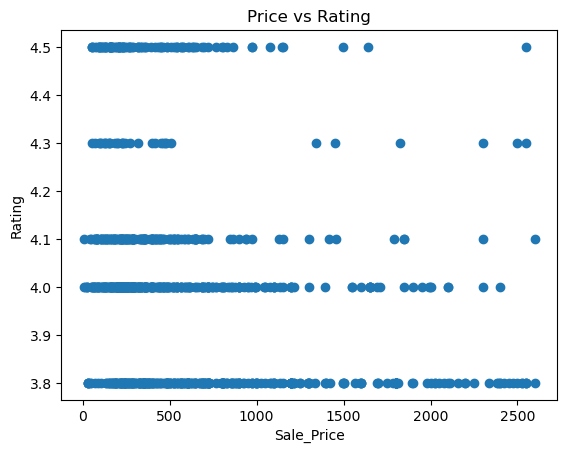

In [23]:
# price vs Rating
plt.scatter(df['Sale_Price'], df['Rating'])
plt.xlabel("Sale_Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

## Insight:
- Higher price ≠ always higher rating

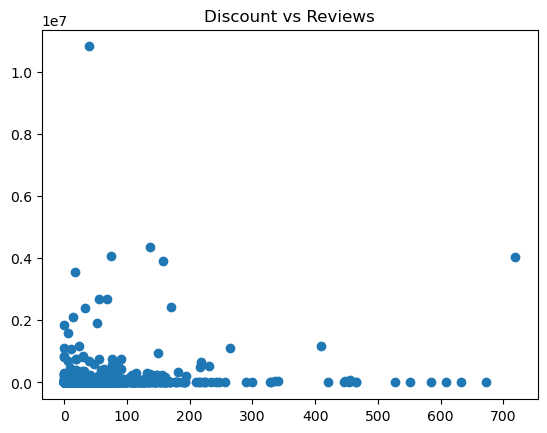

In [28]:
## Discount vs Sales (Reviews)
plt.scatter(df['Discount_Amount'], df['Reviews_Count'])
plt.title("Discount vs Reviews")
plt.show()

## Insight:
- Higher discounts often increase engagement

## Multivariate Analysis

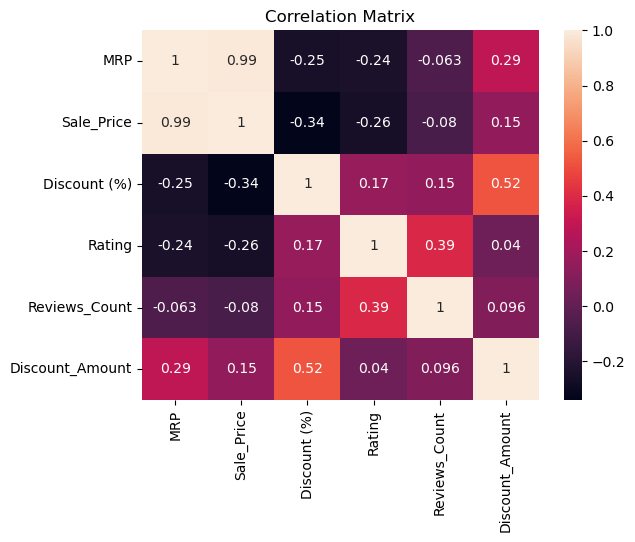

In [31]:
## Correlation Heatmap
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Insight:
>- Strong relationships between:
- Price & MRP
- Discount & Discount Amount

In [33]:
# GroupBy Analysis
df.groupby('Brand')['Sale_Price'].mean().sort_values(ascending=False).head()

Brand
MAKE         2600.00
Clinique     2350.00
Estee        2300.00
Charlotte    2145.75
PAT          2112.00
Name: Sale_Price, dtype: float64

## Insight:
- Premium brands have higher pricing

In [35]:
# Pivot Table
pd.pivot_table(df, values='Sale_Price', index='Category', columns='Brand')

Brand,Anastasia,Be,Beautiliss,Beauty,Benefit,Bioderma,Biotique,Blue,Bobbi,Bronson,...,Tulips,Typsy,Urban,VEGA,VERYMISS,Wanderlust,d'you,e.l.f.,fwee,inde
Category,,,,,,,,,,,,,,,,,,,,,
Makeup,1376.166667,360.05,90.0,1700.0,1745.0,637.2,52.65,109.302778,1831.0,143.3,...,113.925,647.1,2025.0,270.0,181.05,191.2,2000.0,984.782609,1053.1875,721.05


## Interpretations
>## Key Findings:
>- Discounts significantly influence product popularity.
>- Products with higher reviews tend to have better ratings.
>- Mid-range priced products dominate the platform.
>- Premium brands rely less on discounts.

## Final Conclusion
>## Business Insights:
>- Discount strategy is key driver for sales.
>- Customers prefer affordable products with high ratings.
>- High-priced items don’t always guarantee better reviews.
>- Brands should balance price + discount + quality perception.

## FINAL PROJECT SUMMARY
``` This project analyzed Nykaa product data using web scraping and EDA techniques. The study revealed that pricing and discounts play a crucial role in influencing customer behavior. Ratings and reviews showed that customers prioritize value for money rather than just premium branding. The analysis helps businesses optimize pricing strategies and improve product positioning.```